# Agrupamento Hierárquico (Aglomerativo)

O **Agrupamento Hierárquico** (hierarchical clustering) é um dos algoritmos de Machine Learning mais populares para Clustering (agrupamento). Ele é um modelo de aprendizado não supervisionado, o que significa que opera em um conjunto de dados sem rótulos ou alvos (sem a variável target $y$).

Sua principal função é encontrar estruturas e padrões ocultos nos dados, agrupando-os de acordo com a similaridade de suas características. Na abordagem **aglomerativa**, o algoritmo adota uma estratégia *bottom-up* (de baixo para cima), na qual cada ponto de dado começa como seu próprio cluster individual e, a cada passo, os pares de clusters mais próximos são sucessivamente fundidos até que reste apenas um único grande grupo.

## Nota Histórica

Ao contrário do $K$-Means, que nasceu focado em engenharia de sinais, o Agrupamento Hierárquico tem suas raízes profundamente fincadas nas ciências biológicas e na taxonomia. A necessidade de classificar seres vivos em reinos, filos, classes e espécies criou a demanda por uma matemática que representasse hierarquias (árvores).

O primeiro grande marco computacional ocorreu em 1958, quando **Robert Sokal** e **Charles Michener** publicaram um artigo revolucionário sobre "Taxonomia Numérica", propondo algoritmos aglomerativos para classificar espécies de abelhas. Poucos anos depois, em 1963, **Joe H. Ward** introduziu o famoso "Método de Ward", que uniu a hierarquia ao conceito de minimização de variância. Hoje, o método transcendeu a biologia e é uma ferramenta fundamental em análise de dados, genômica e finanças.

---

## Vantagens e Desvantagens

O Agrupamento Hierárquico resolve alguns dos maiores problemas do K-Means, mas introduz seus próprios desafios computacionais.

**Vantagens:**

* **Não exige o $K$ inicial:** Você não precisa saber quantos clusters existem antes de rodar o modelo. O algoritmo constrói toda a árvore geométrica e você pode "cortá-la" onde achar mais adequado.

* **Interpretabilidade Visual (Dendrograma):** Produz um gráfico em formato de árvore (o Dendrograma) que mostra exatamente não apenas *quais* pontos foram agrupados, mas *em que ordem* e *a qual distância*. É excelente para apresentações de negócios.

* **Múltiplos Critérios de Ligação:** Dependendo do critério escolhido (*Single, Complete, Average* ou *Ward*), o modelo consegue identificar clusters com formatos complexos (como anéis ou meias-luas), superando a limitação esférica do K-Means.

**Desvantagens:**

* **Custo Computacional Alto:** Esta é sua maior fraqueza. A complexidade de tempo padrão é $\mathcal{O}(n^3)$ e a de espaço (memória) é $\mathcal{O}(n^2)$, já que ele precisa calcular e armazenar a distância de todos os pontos contra todos os pontos. É inviável para *Big Data* (milhões de linhas).

* **Sensibilidade a Ruídos:** Alguns métodos de ligação (como o *Single Linkage*) sofrem gravemente com o "efeito de encadeamento" (*chaining*), onde um único *outlier* ou ponto de ruído pode atuar como uma ponte, unindo indevidamente dois clusters distintos.

* **Irreversibilidade:** Uma vez que o algoritmo decide unir dois pontos ou clusters em uma iteração, essa decisão matemática é final e não pode ser desfeita nos passos seguintes, mesmo que se revele uma escolha ruim mais à frente.

---

## Principais Casos de Uso

Devido ao seu alto custo computacional, o Agrupamento Hierárquico brilha em conjuntos de dados de tamanho pequeno a médio, especialmente onde a **relação de parentesco** entre os dados é tão importante quanto o agrupamento final:

* **Bioinformática e Genômica:** Agrupar sequências de DNA ou perfis de expressão gênica para construir árvores filogenéticas (mostrando a distância evolutiva entre espécies ou mutações de vírus).

* **Organização de Documentos e Taxonomia:** Criar hierarquias automáticas de tópicos em milhares de textos (ex: agrupar notícias de esporte -> subdividir em futebol e basquete -> subdividir em times locais).

* **Análise de Redes de Computadores ou Sociais:** Identificar comunidades dentro de redes, descobrindo subgrupos menores dentro de grupos maiores de amigos ou servidores.

* **Detecção de Fraudes Financeiras:** Analisar transações suspeitas em pequenas janelas de tempo, onde visualizar a "árvore" de transferências ajuda a entender a hierarquia da lavagem de dinheiro.

-------------------

## Formulação Matemática

Suponha que tenhamos um conjunto de dados com $d$ amostras, no qual cada amostra possui $N$ características (dimensões). Podemos representar esse conjunto de dados como:

$$X = \begin{pmatrix} \vec{x}_1 \\ \vec{x}_2 \\ \vdots \\ \vec{x}_d \end{pmatrix} = \begin{pmatrix}
\lambda_1^{(1)} & \lambda_2^{(1)} & \dots & \lambda_N^{(1)} \\
\lambda_1^{(2)} & \lambda_2^{(2)} & \dots & \lambda_N^{(2)} \\
\vdots & \vdots & \ddots & \vdots \\
\lambda_1^{(d)} & \lambda_2^{(d)} & \dots & \lambda_N^{(d)}
\end{pmatrix},$$
no qual cada dado $\vec{x}_i$​ é um vetor de características em um espaço multidimensional:

$$\vec{x}_i ​= (\lambda_1^{(i)}​, \lambda_2^{(i)}​,... , \lambda_N^{(i)}​) \in \mathbb{R}^N.$$

O objetivo do algoritmo é construir uma hierarquia de agrupamentos. Na abordagem **aglomerativa**, começamos com o cenário mais fragmentado possível: cada vetor de dados $\vec{x}_i$ é tratado como um único cluster isolado. Assim, no passo inicial, temos $d$ clusters:

$$
S_1 = \{\vec{x}_1\},..., S_d = \{\vec{x}_d\}.
$$

A cada iteração, o algoritmo funde os dois clusters mais "próximos" em um só, reduzindo o número total de clusters em 1, até que todos os dados pertençam a um único grande cluster.

Para decidir quais clusters devem ser unidos, definimos primeiro uma métrica de distância básica entre dois vetores individuais, como a Distância Euclidiana por exemplo:

$$
d(\vec{x}, \vec{y}) = ||\vec{x} - \vec{y}||_{L_2}
$$

Em seguida, definimos um **Critério de Ligação (Linkage)** $D(S_A, S_B)$, que atua como uma regra para medir a distância entre os conjuntos (clusters) $S_A$ e $S_B$. O algoritmo sempre buscará fundir os clusters que minimizem a função $D$.

Os quatro critérios de ligação mais comuns na literatura são:

* **1. Ligação Simples (Single Linkage)**: A distância entre dois clusters é definida como a distância entre os seus dois pontos **mais próximos**. Tende a criar clusters alongados e sofre com o efeito de "encadeamento".

$$
D(S_A, S_B) = \min_{\vec{x} \in S_A, \vec{y} \in S_B} d(\vec{x}, \vec{y})
$$

* **2. Ligação Completa (Complete Linkage)**: A distância entre dois clusters é a distância entre os seus dois pontos **mais distantes**. Garante que os clusters formados sejam altamente compactos, forçando um formato esférico.

$$
D(S_A, S_B) = \max_{\vec{x} \in S_A, \vec{y} \in S_B} d(\vec{x}, \vec{y})
$$

* **3. Ligação Média (Average Linkage / UPGMA)**: Calcula a média de todas as distâncias possíveis entre os pontos do cluster $S_A$ e os pontos do cluster $S_B$. É um excelente meio-termo, onde $|S|$ representa a cardinalidade (número de elementos) do cluster.

$$
D(S_A, S_B) = \frac{1}{|S_A| |S_B|} \sum_{\vec{x} \in S_A} \sum_{\vec{y} \in S_B} d(\vec{x}, \vec{y})
$$

* **4. Método de Ward (Ward's Linkage)**: Diferente das abordagens puramente baseadas em distância, o Método de Ward é baseado em **variância**. Ele calcula o aumento na Soma dos Quadrados Intra-Cluster (Inércia / WCSS) que ocorreria se $S_A$ e $S_B$ fossem fundidos. Ele une os clusters que resultam no **menor aumento** da variância.

$$
D(S_A, S_B) = \sum_{\vec{x} \in S_A \cup S_B} ||\vec{x} - \vec{\mu}_{A \cup B}||^2 - \sum_{\vec{x} \in S_A} ||\vec{x} - \vec{\mu}_A||^2 - \sum_{\vec{x} \in S_B} ||\vec{x} - \vec{\mu}_B||^2,
$$

em que $\vec{\mu}$ é o centroide do respectivo cluster).

### O Processo do Algoritmo:

1. **Iteração:** A cada passo, calcule a distância $D(A_i, A_j)$ entre todos os clusters atuais.

2. **Fusão:** Encontre os dois clusters $A_i$ e $A_j$ que minimizam o classificador $D$.

3. **Atualização:** Mescle $A_i$ e $A_j$ em um único novo cluster. O número total de clusters diminui em um.

4. **Finalização:** Repita o processo até que todos os pontos sejam mesclados em um único cluster contendo $N$ pontos, ou até que um limite de distância predefinido seja atingido.

### Visualização: O Dendrograma
O resultado dessa hierarquia é tipicamente visualizado usando um **Dendrograma**, um diagrama em forma de árvore onde o eixo y representa a distância na qual os agrupamentos foram unidos. Ao "cortar" a árvore em uma determinada altura, determinamos o número final de agrupamentos.

### Critérios de Parada (Quando o algoritmo termina?)

Diferente do K-Means, que para de iterar quando os centroides atingem a convergência (não se movem mais), o Agrupamento Hierárquico Aglomerativo, por natureza, continuará fundindo grupos até que reste apenas **um único e gigantesco cluster** contendo todos os dados originais.

Para obtermos agrupamentos úteis na prática, precisamos definir um **Critério de Parada**. Existem três abordagens principais na literatura:

1. **Construção Total e Corte (Post-hoc):**
   É a abordagem mais comum em análise exploratória (utilizada pela biblioteca `SciPy`). O algoritmo roda até o fim, fundindo todos os $d$ pontos em 1 único cluster. Depois, desenhamos o Dendrograma e escolhemos visualmente uma **linha de corte horizontal**. Todos os galhos interceptados por essa linha tornam-se os clusters finais.

2. **Número Fixo de Clusters ($K$ predefinido):**
   Se o problema de negócio já exige um número específico de grupos (por exemplo, separar clientes em "Baixo, Médio e Alto Risco"), instruímos o algoritmo a interromper o laço `while` assim que o número de clusters restantes for exatamente igual a $K$. *(Nota: Foi exatamente esse o critério que utilizamos na nossa implementação manual em Python, definindo `target_k = 3`).*

3. **Limite de Distância Mínima (Threshold de Similaridade):**
   Neste cenário, não definimos o número de clusters, mas sim o limite do "quão diferentes" dois grupos podem ser para serem unidos. O algoritmo é interrompido no momento em que a distância $D(S_i, S_j)$ entre os dois clusters mais próximos for **maior** que um limite predefinido $D_{max}$. Se a fusão for custar muito em termos de variância (ou distância), o algoritmo entende que os grupos restantes são fundamentalmente distintos e encerra o processo.

4. **A Regra dos 70% (Heurística de Distância Máxima):**
   Uma "regra de bolso" amplamente utilizada em ciência de dados que estabelece a linha de corte do dendrograma em **$70\%$ da sua altura máxima** (a distância onde ocorre a fusão final de todos os pontos). Definindo o limiar como $t = 0.7 \times d_{max}$, o algoritmo consegue isolar os macro-grupos verdadeiros antes que eles sejam forçados a se fundir na raiz, ignorando eficientemente os ruídos e as pequenas fusões da base da árvore.
-------------------------------------

## Exemplo

Primeiramente, geraremos pseudodados sintéticos para facilitar a análise. Os pseudodados consistirão em pontos aleatórios distribuídos dentro de três elipses, definidas pela seguinte desigualdade:

$$\frac{(x-x_0)^2}{a^2} + \frac{(y-y_0)^2}{b^2} \leq 1$$

Usando Python, vamos gerar pares de coordenadas $(x, y)$, em que $x \in [x_0 - a, x_0 + a]$ é um número aleatório e $y$ é um número aleatório limitado por:

$$-b\sqrt{1 -\frac{(x-x_0)^2}{a^2}} + y_0 \leq y \leq b\sqrt{1 -\frac{(x-x_0)^2}{a^2}} + y_0.$$

**Ideia:** o objetivo é dar as coordenadas cartesianas de um ponto gerado aleatoriamente, $\vec{x} := (\lambda_1, \lambda_2):= (x, y)$, sem a "label" de qual elipse ele pertence. O algoritmo deve ser capaz de agrupar os pontos nas elipses corretas.

Para esse problema, temos $N=2$ características, a saber, as coordenadas cartesianas $(x, y)$, e o número $d$ de dados é o número de pontos aleatórios gerados.

**Nota:** diferente do K-Means, o Agrupamento Hierárquico manual em Python puro (sem vetorização avançada) é extremamente lento. Por isso, na implementação manual, vamos gerar poucos pontos.

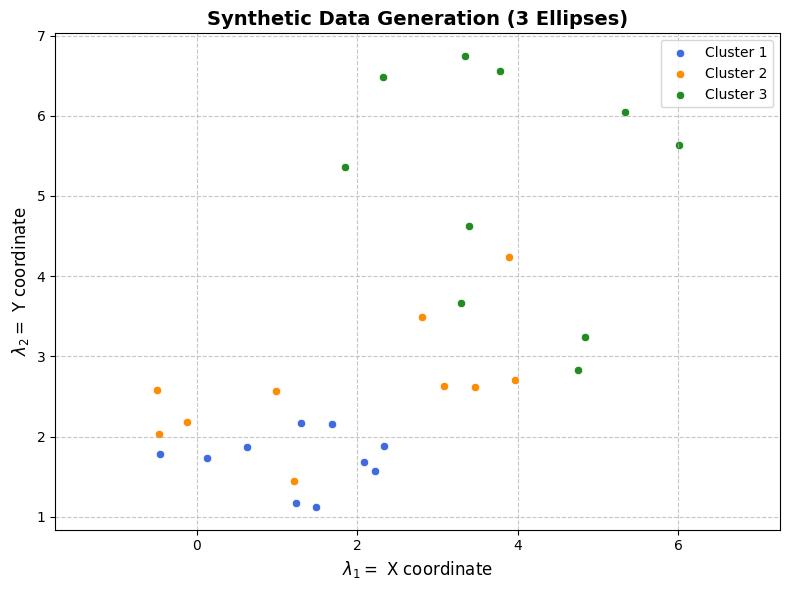

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#-------------------------------------
# We have
N = 2 # characteristics, namely, x and y coordinate

# Number os random points generated in each ellipse
d_1 = 10
d_2 = 10
d_3 = 10
# We generate few points because the manual implementations is very slow

#Sample number
d = d_1 + d_2 + d_3

#-------------------------------------
# Pseudo-data generation - we generate d_points random numbers in [x0 - a, x0 + a] through an uniform distribution

def xy_gen(d_points, x0, y0, a, b):

    x_min = x0 - a
    x_max = x0 + a

    # np.random.uniform(limite_inferior, limite_superior, quantidade)
    x = np.random.uniform(x_min, x_max, d_points)

    y_min = y0 - b*np.sqrt(1.0 - ((x-x0)/a)**2)
    y_max = y0 + b*np.sqrt(1.0 - ((x-x0) /a)**2)

    y = np.random.uniform(y_min, y_max, d_points)

    return (x, y)

#-------------------------------------
# Graph generator

# 1. Generating the pseudo-data for 3 ellipses (clusters)
x1, y1 = xy_gen(d_1, x0=1, y0=2, a=1.5, b=1.0)
c1 = np.full(d_1, 'royalblue')

x2, y2 = xy_gen(d_2, x0=2, y0=3, a=3.0, b=1.8)
c2 = np.full(d_2, 'darkorange')

x3, y3 = xy_gen(d_3, x0=4, y0=5, a=2.2, b=2.5)
c3 = np.full(d_3, 'forestgreen')

#The color label c is only for the final comparison of the results

#-------------------------------------
# We create the X: all points in a single matrix

x_all = np.concatenate([x1, x2, x3])
y_all = np.concatenate([y1, y2, y3])
c_all = np.concatenate([c1, c2, c3])

X = np.column_stack((x_all, y_all)) # Ordered pairs [[x, y], [x, y], ...]

# We create a vector with the color label for the comparison of the figures in the final
X_label = np.column_stack((x_all, y_all, c_all)) # Ordered pairs [[x, y], [x, y], ...]

# Extracting colors directly from X_label (Your logic)
colors_labeled = []

for j in range(len(X)):
    coordinate_color = X_label[j, 2]
    colors_labeled.append(coordinate_color)

#-------------------------------------------------------------------
# FIGURES
#-------------------------------------------------------------------

# 2. Figure configuration
plt.figure(figsize=(8, 6))

# 3. Plot. The scatter don't join the points with a line as the plot. Alpha channel controls the transparency of the points alpha = 0, the point is invisible
plt.scatter(x1, y1, color=c1[0], alpha=1, edgecolors='w', linewidth=0.5, label='Cluster 1')
plt.scatter(x2, y2, color=c2[0], alpha=1, edgecolors='w', linewidth=0.5, label='Cluster 2')
plt.scatter(x3, y3, color=c3[0], alpha=1, edgecolors='w', linewidth=0.5, label='Cluster 3')

# 4. Labels
plt.title('Synthetic Data Generation (3 Ellipses)', fontsize=14, fontweight='bold')
plt.xlabel(r'$\lambda_1 =$ X coordinate', fontsize=12)
plt.ylabel(r'$\lambda_2 =$ Y coordinate', fontsize=12)

# Axis x and y have the same scale
plt.axis('equal')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 5. Save and show the graph
plt.tight_layout()
plt.savefig('pseudo_data_ellipses.png', dpi=300)
plt.show()

## O Algoritmo na Prática

Em nosso caso das elipses, geramos um conjunto com $d$ coordenadas cartesianas:

$$
X = \{(x_1, y_1), (x_2, y_2), \dots, (x_d, y_d)\}
$$

Inicialmente, a abordagem aglomerativa considera $d$ conjuntos (clusters) distintos, ou seja, cada ponto é seu próprio universo:

$$
S_1 = \{(x_1, y_1)\}, S_2 = \{(x_2, y_2)\}, \dots, S_d = \{(x_d, y_d)\}
$$

A métrica base utilizada para medir a distância entre dois pontos é a distância euclidiana. Para realizar as fusões, utilizaremos a biblioteca `SciPy` para calcular a matriz de ligação (usando o Método de Ward) e desenhar o **Dendrograma**, e em seguida o `Scikit-Learn` para agrupar e visualizar as elipses finais.

Nós escolhemos Classifier (Single Linkage) para ser a menor distância entre os dois conjuntos.

Starting with 30 clusters...


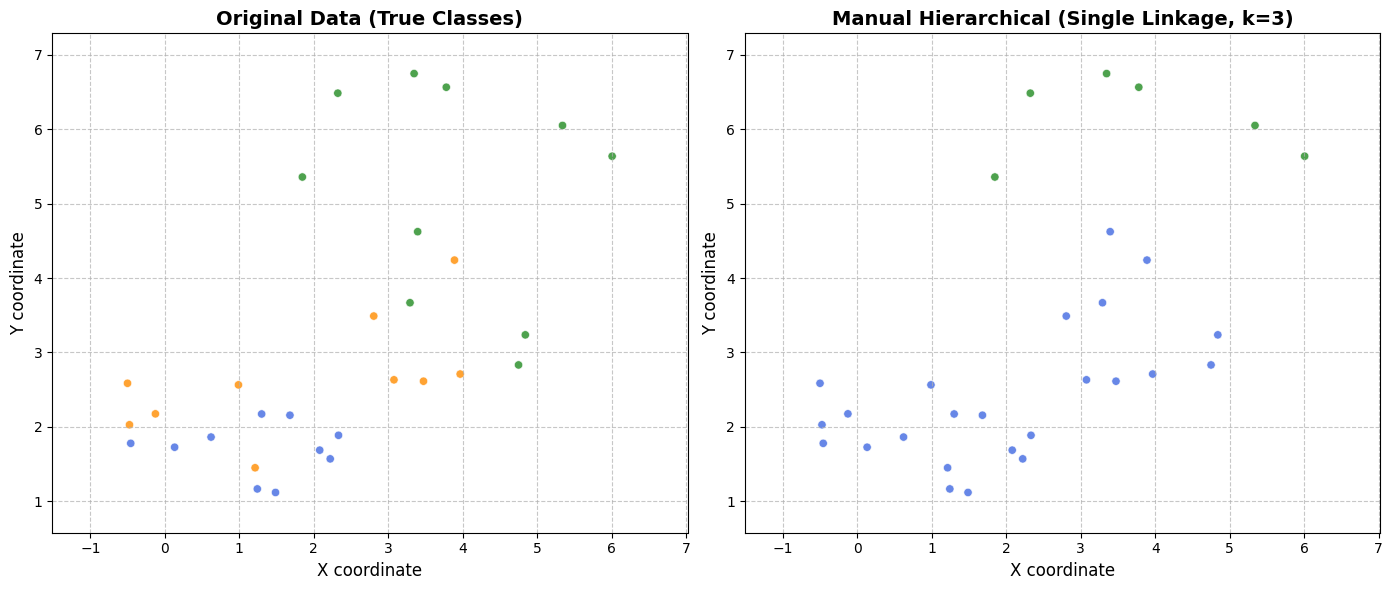

In [5]:
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

#------------------------------------------------------------------
# HIERARCHICAL CLUSTERING MANUAL (SINGLE LINKAGE)
#------------------------------------------------------------------

# 2. Initialization: Each point is a cluster
clusters = [[i] for i in range(len(X))]

# We choose the metric: euclidean in this case
def euclidean_distance(p1, p2):
    """Euclidean Metric"""
    return np.sqrt(np.sum((p1 - p2)**2))

def D(cluster_i, cluster_j, data):
    """Classifier (Single Linkage): Shortest distance between two sets"""
    min_dist = np.inf
    for idx_i in cluster_i:
        for idx_j in cluster_j:
            dist = euclidean_distance(data[idx_i], data[idx_j])
            if dist < min_dist:
                min_dist = dist
    return min_dist

# 3. Manual Clustering Process
# We will reduce until only 'target_k' clusters remain
target_k = 3

print(f"Starting with {len(clusters)} clusters...")
print("Warning: The manual process with 300 points might take a few minutes. Please wait...")

while len(clusters) > target_k:
    min_dist_global = np.inf
    to_merge = (0, 0)

    # Find the two closest clusters according to classifier D
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            dist_clusters = D(clusters[i], clusters[j], X)
            if dist_clusters < min_dist_global:
                min_dist_global = dist_clusters
                to_merge = (i, j)

    # Merge the two sets (A_i U A_j)
    idx_i, idx_j = to_merge
    clusters[idx_i].extend(clusters[idx_j])
    clusters.pop(idx_j)

    if len(clusters) % 50 == 0:
        print(f"Remaining clusters: {len(clusters)}")

#---------------------------------------------------------------------
# FIGURES
#---------------------------------------------------------------------

# 4. Assigning Labels for the Plot
labels_manual = np.zeros(len(X))
for cluster_id, points_indices in enumerate(clusters):
    for idx in points_indices:
        labels_manual[idx] = cluster_id

# 5. Visualization: Original vs Manual Hierarchical Clustering
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Graph 1: Original Data ---
# We use 'colors_labeled' to show the true ground truth of the generated ellipses
ax1.scatter(X[:, 0], X[:, 1], color=colors_labeled, alpha=0.8, edgecolors='w', linewidth=0.5)
ax1.set_title('Original Data (True Classes)', fontsize=14, fontweight='bold')
ax1.set_xlabel("X coordinate", fontsize=12)
ax1.set_ylabel("Y coordinate", fontsize=12)
ax1.axis('equal')
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Graph 2: Manual Hierarchical Clustering Result ---
# We use 'labels_manual' to show the output of our Single Linkage algorithm
# --- Graph 2: Manual Hierarchical Clustering Result ---
# 1. Calculate centroids for the formed clusters and match colors
centroid_colors_manual = {}
for cluster_id in np.unique(labels_manual):
    # Calculate the mean (centroid) of the points in this cluster
    cluster_points = X[labels_manual == cluster_id]
    centroid = np.mean(cluster_points, axis=0)

    # Find the closest original point to this centroid
    distances = [euclidean_distance(centroid, X[i]) for i in range(len(X))]
    closest_idx = np.argmin(distances)
    centroid_colors_manual[cluster_id] = colors_labeled[closest_idx]

# 2. Map the labels to the true colors
pred_colors_manual = [centroid_colors_manual[label] for label in labels_manual]

# 3. Plot with the matched colors
ax2.scatter(X[:, 0], X[:, 1], color=pred_colors_manual, alpha=0.8, edgecolors='w', linewidth=0.5)

ax2.set_title(f"Manual Hierarchical (Single Linkage, k={target_k})", fontsize=14, fontweight='bold')
ax2.set_xlabel("X coordinate", fontsize=12)
ax2.set_ylabel("Y coordinate", fontsize=12)
ax2.axis('equal')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('hierarchical_manual_comparison.png', dpi=300)
plt.show()

## Métricas de Avaliação do Modelo

Avaliar a qualidade de um Agrupamento Hierárquico segue a mesma filosofia que utilizamos no K-Means, pois ambos são algoritmos não supervisionados. Como nós mesmos geramos nossos dados sintéticos e sabemos exatamente a qual elipse cada ponto pertence (nosso "gabarito" guardado na variável `colors_labeled`), podemos usar uma abordagem robusta combinando métricas intrínsecas e extrínsecas.

### 1. Coeficiente de Silhueta (Silhouette Score)

A Silhueta é uma métrica **intrínseca**. Ela não precisa saber as respostas reais; ela avalia puramente a geometria dos clusters criados. O objetivo é medir duas coisas: a **coesão** (quão próximos os pontos de um mesmo cluster estão entre si) e a **separação** (quão distantes eles estão do cluster vizinho).

Para um único ponto, a silhueta $s$ é calculada da seguinte forma:

$$
s = \frac{b - a}{\max(a, b)}
$$

Em que:
* $a$ é a distância média do ponto para todos os outros pontos do **seu próprio** cluster.
* $b$ é a distância média do ponto para todos os pontos do **cluster vizinho mais próximo**.

**Interpretação:** O valor varia de $-1$ a $1$.
* Valores próximos a **$1$** indicam que os pontos estão em clusters densos e bem separados dos demais.
* Valores próximos a **$0$** indicam que os clusters estão se sobrepondo ou encostando.
* Valores próximos a **$-1$** indicam que os pontos provavelmente foram alocados em clusters incorretos.

### 2. Índice de Rand Ajustado (Adjusted Rand Index - ARI)

O ARI é uma métrica **extrínseca**. Ele exige que tenhamos os rótulos verdadeiros (as nossas elipses originais) para comparar com as predições do algoritmo.

Ele conta todos os pares de pontos e verifica se os pares que estavam juntos na mesma elipse também foram colocados juntos pelo nosso Agrupamento Hierárquico. O termo "Ajustado" significa que a métrica é corrigida matematicamente para o acaso (evitando que um algoritmo ganhe pontos apenas por chutar agrupamentos aleatórios).

**Interpretação:** O valor varia de $-1$ a $1$.
* Um escore de **$1.0$** indica agrupamentos idênticos ao gabarito perfeito (o modelo reconstruiu as elipses exatamente como nós as geramos).
* Um escore próximo a **$0.0$** indica marcações puramente aleatórias.

*(Nota técnica: Em projetos específicos de Agrupamento Hierárquico, também é altamente recomendável avaliar o **Coeficiente de Correlação Cofenética**, uma métrica que mede o quão fielmente a "árvore" desenhada no Dendrograma preservou as distâncias par-a-par originais dos dados matemáticos).*


     HIERARCHICAL CLUSTERING EVALUATION METRICS
1. Silhouette Score:          0.4282  (Closer to 1.0 is better)
2. Adjusted Rand Index (ARI): 0.1252  (Closer to 1.0 is better)


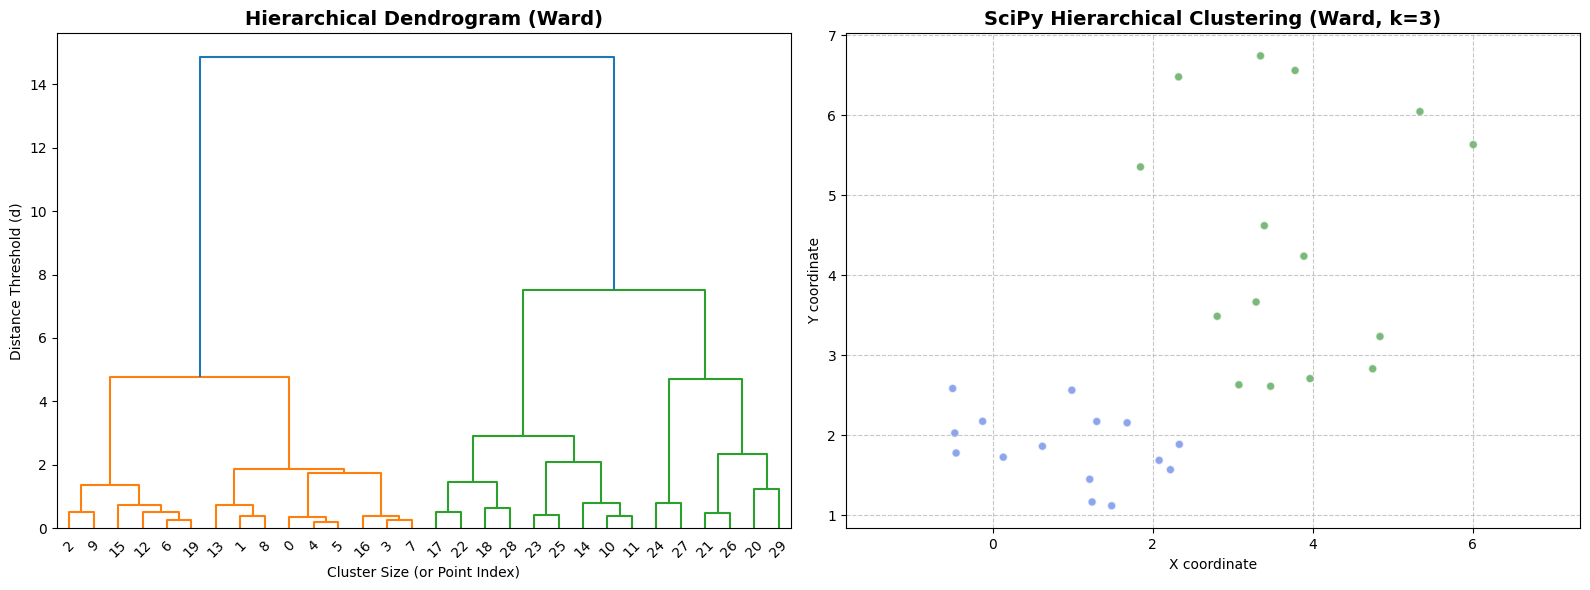

In [7]:
#------------------------------------------------------------------
# METRICS EVALUATION
#------------------------------------------------------------------

hc_sil_score = silhouette_score(X, labels_manual)
hc_ari_score = adjusted_rand_score(colors_labeled, labels_manual)

print("\n" + "="*50)
print("     HIERARCHICAL CLUSTERING EVALUATION METRICS")
print("="*50)
print(f"1. Silhouette Score:          {hc_sil_score:.4f}  (Closer to 1.0 is better)")
print(f"2. Adjusted Rand Index (ARI): {hc_ari_score:.4f}  (Closer to 1.0 is better)")
print("="*50)

#------------------------------------------------------------------
# HIERARCHICAL CLUSTERING SCIPY (WARD LINKAGE)
#------------------------------------------------------------------

# 2. Generating the Linkage Matrix
# 'ward' is great for ellipses as it minimizes the variance.
Z = linkage(X, method='ward')

# 3. Creating the comparative figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Graph 1: The Dendrogram ---
# 'truncate_mode' helps not to pollute the graph with 300 lines at the base
dendrogram(Z, ax=ax1, leaf_rotation=45)
ax1.set_title("Hierarchical Dendrogram (Ward)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Cluster Size (or Point Index)")
ax1.set_ylabel("Distance Threshold (d)")

# --- Graph 2: The Result in 2D Space ---
# Let's cut the tree at k=3 to compare with K-Means
k = 3
labels_h = fcluster(Z, k, criterion='maxclust')

# 1. Calculate centroids for SciPy clusters and match colors
centroid_colors_scipy = {}
for cluster_id in np.unique(labels_h):
    cluster_points = X[labels_h == cluster_id]
    centroid = np.mean(cluster_points, axis=0)

    distances = [euclidean_distance(centroid, X[i]) for i in range(len(X))]
    closest_idx = np.argmin(distances)
    centroid_colors_scipy[cluster_id] = colors_labeled[closest_idx]

# 2. Map the labels to the true colors
pred_colors_scipy = [centroid_colors_scipy[label] for label in labels_h]

# 3. Plot with the matched colors
ax2.scatter(X[:, 0], X[:, 1], color=pred_colors_scipy, alpha=0.6, edgecolors='w')

ax2.set_title(f"SciPy Hierarchical Clustering (Ward, k={k})", fontsize=14, fontweight='bold')
ax2.set_xlabel("X coordinate")
ax2.set_ylabel("Y coordinate")
ax2.axis('equal')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('hierarchical_comparison.png', dpi=300)
plt.show()

## Conclusão e Próximos Passos

Chegamos ao fim deste estudo profundo sobre a base dos algoritmos de aprendizado não supervisionado. Ao longo deste projeto, saímos do uso superficial de caixas-pretas de bibliotecas prontas e mergulhamos na fundação matemática e geométrica que faz esses modelos funcionarem.

Implementar o **K-Means** e o **Agrupamento Hierárquico** "na unha" (*from scratch*) exigiu traduzir cálculo vetorial, distâncias euclidianas e lógicas iterativas para código Python puro. Esse nível de rigor analítico é exatamente o que fundamenta aplicações do mundo real — seja para criar soluções de otimização em dados financeiros complexos ou para identificar padrões ocultos em grandes volumes de dados experimentais.

### Qual Algoritmo Escolher?

Como vimos na prática, não existe um "modelo perfeito", mas sim a ferramenta matemática certa para o contexto e a topologia dos dados:

| Característica | K-Means | Agrupamento Hierárquico |
| :--- | :--- | :--- |
| **Definição de Grupos** | Exige a definição prévia do número de clusters ($K$). | A hierarquia revela os agrupamentos naturalmente (corte no Dendrograma). |
| **Performance e Escala** | Muito eficiente computacionalmente. Excelente para processamento em larga escala. | Custo computacional elevado. Estrategicamente ideal para conjuntos de dados pequenos a médios. |
| **Premissa Geométrica** | Assume que os grupos são esféricos e com variâncias similares. | Altamente flexível. Pode se adaptar a formas não-globulares dependendo do critério de ligação (*Linkage*). |
| **Interpretabilidade** | Direta, baseada na posição das coordenadas dos Centroides. | Altamente visual, permitindo rastrear o histórico de fusões pela árvore do Dendrograma. |

### Explorando Novos Horizontes

O universo do aprendizado não supervisionado é vasto. Com a base sólida construída aqui, caminhos naturais para a evolução deste repositório incluem:

* **DBSCAN:** Explorar algoritmos puramente baseados em densidade geométrica, capazes de identificar agrupamentos de formatos completamente arbitrários e de isolar ativamente ruídos (*outliers*).
* **Redução de Dimensionalidade (PCA):** Estudar métodos baseados em autovalores e autovetores para comprimir dados multidimensionais em espaços 2D ou 3D, preservando a variância original para possibilitar a visualização de fenômenos complexos.

Obrigado por explorar este repositório! Sinta-se à vontade para clonar o projeto, alterar as sementes aleatórias de geração de dados e observar, na prática, a mecânica interna desses modelos ganhando vida.